# Dataset 2: Depression Dataset

New dataset experimentation.

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns

LABEL = 'Depression'  # Target variable

In [70]:
df = pd.read_csv('data/dataset2/depression_dataset.csv')
df_initial = df.copy()
df.head()

,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression,original
0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0,0
1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1,0
2,Yuvraj,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1,0
3,Yuvraj,Male,22.0,Mumbai,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1,0
4,Rhea,Female,30.0,Kanpur,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0,0


For this particular dataset, it was specified in the source that the original column helps to determine whether that row comes from the original survey, or from the mixture between a provided train data set (same columns) and the original dataset. This was to increment the amount of rows that were going to be used for the model to be trained on.

## 1) Clean the data


Dropping unuseful columns as they are not useful for the model:

In [71]:
df.drop(columns=['Name','City','original'], inplace=True)
df.head()

,Gender,Age,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Female,49.0,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,Male,26.0,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,Male,33.0,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,Male,22.0,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,Female,30.0,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0


In [72]:
# Renaming columns for easier access
df = df.rename(columns={"Have you ever had suicidal thoughts ?": "Suicidal_Thoughts",
                        "Working Professional or Student": "Work_Student_Status"})
df.head()

,Gender,Age,Work_Student_Status,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Suicidal_Thoughts,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Female,49.0,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,Male,26.0,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,Male,33.0,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,Male,22.0,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,Female,30.0,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143256 entries, 0 to 143255
Data columns (total 17 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   Gender                            143256 non-null  object 
 1   Age                               143256 non-null  float64
 2   Work_Student_Status               143256 non-null  object 
 3   Profession                        105953 non-null  object 
 4   Academic Pressure                 28399 non-null   float64
 5   Work Pressure                     114836 non-null  float64
 6   CGPA                              28400 non-null   float64
 7   Study Satisfaction                28399 non-null   float64
 8   Job Satisfaction                  114844 non-null  float64
 9   Sleep Duration                    143256 non-null  object 
 10  Dietary Habits                    143252 non-null  object 
 11  Degree                            143254 non-null  o

Columns such as work pressure, job satisfaction, study satisfaction CGPA and academic pressure have a significant amount of missing values. Let's see how are these missing values behaving:

In [74]:
# create a tidy DataFrame showing missing value percentages per column
def missing_report(df):
    missing = df.isnull().mean().mul(100)
    missing_df = missing.reset_index()
    missing_df.columns = ['Columns', 'Missing Values Percentage']
    return missing_df

missing_df = missing_report(df)
missing_df

,Columns,Missing Values Percentage
0,Gender,0.000000
1,Age,0.000000
2,Work_Student_Status,0.000000
3,Profession,26.039398
4,Academic Pressure,80.176048
5,Work Pressure,19.838611
6,CGPA,80.175350
7,Study Satisfaction,80.176048
8,Job Satisfaction,19.833026
9,Sleep Duration,0.000000


So, the columns that miss most of the values seem to be student specific. Let's try to verify that by splitting the same analysis by students and workers

In [75]:
missing_df['Student Missing Percentage'] = df[df['Work_Student_Status'] == 'Student'].isnull().mean().mul(100).values
missing_df['Professional Missing Percentage'] = df[df['Work_Student_Status'] == 'Working Professional'].isnull().mean().mul(100).values
missing_df[missing_df['Missing Values Percentage'] > 0]

,Columns,Missing Values Percentage,Student Missing Percentage,Professional Missing Percentage
3,Profession,26.039398,99.880294,7.778639
4,Academic Pressure,80.176048,0.031687,99.995647
5,Work Pressure,19.838611,99.989438,0.017414
6,CGPA,80.175350,0.031687,99.994776
7,Study Satisfaction,80.176048,0.035208,99.994776
8,Job Satisfaction,19.833026,99.971834,0.014802
10,Dietary Habits,0.002792,0.007042,0.001741
11,Degree,0.001396,0.000000,0.001741
14,Financial Stress,0.002792,0.010562,0.000871


This is the proof that the values are missing because those columns are case sensitive and apply only to whether the person was a student or a worker. In order to handle this properly, I'll create a new column that will be a binary flag that will determine whether the person is a student or a worker (1 for working professional, 0 for student).

In [76]:
df.head()

,Gender,Age,Work_Student_Status,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Suicidal_Thoughts,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Female,49.0,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,Male,26.0,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,Male,33.0,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,Male,22.0,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,Female,30.0,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0


In [77]:
# Defining columns related to students and professionals
student_cols = ['Academic Pressure', 'CGPA', 'Study Satisfaction']
prof_cols    = ['Work Pressure', 'Job Satisfaction']

df['Work_Student_Status'] = (df['Work_Student_Status'].str.lower() == 'Working Professional'.lower()).astype(int)

Now, we can safely replace values implementing this logic:
- If the row talks about a professional, the `Work_Student_Status` flag is equal to 1, and the professional columns are displayed normally, every other column values take the sentinel = -1 value. This is intended to help future models learn and avoid taking this case into account. 
- If the row talks about a student, the `Work_Student_Status` flag is equal to 0, and the student columns are displayed normally, every other column values take the sentinel = -1 value. This is intended to help future models learn and avoid taking this case into account. 

`Work_Student_Status` column is now a binary flag, where 1 means the row is about a professional, and 0 means the row is about a student.

Let's implement this logic in code:


In [78]:
for col in student_cols:
    # compute student median (skip NaNs)
    median_student = df.loc[df['Work_Student_Status']==0, col].median()
    # impute for students
    df.loc[(df['Work_Student_Status']==0) & (df[col].isnull()), col] = median_student
    # for non-students, set sentinel -1 (or choose other sentinel)
    df.loc[df['Work_Student_Status']==1, col] = -1

for col in prof_cols:
    # compute professional median (skip NaNs)
    median_prof = df.loc[df['Work_Student_Status']==1, col].median()
    # impute for professionals
    df.loc[(df['Work_Student_Status']==1) & (df[col].isnull()), col] = median_prof
    df.loc[df['Work_Student_Status']==0, col] = -1
df.head()

,Gender,Age,Work_Student_Status,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Suicidal_Thoughts,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Female,49.0,1,Chef,-1.0,5.0,-1.00,-1.0,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,Male,26.0,1,Teacher,-1.0,4.0,-1.00,-1.0,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,Male,33.0,0,NaN,5.0,-1.0,8.97,2.0,-1.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,Male,22.0,1,Teacher,-1.0,5.0,-1.00,-1.0,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,Female,30.0,1,Business Analyst,-1.0,1.0,-1.00,-1.0,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0


Now, we can verify the dataset null values as follows:

### Checking Duplicates

In [79]:
df[df.duplicated(keep = False)].sort_values(list(df.columns))

,Gender,Age,Work_Student_Status,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Suicidal_Thoughts,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
11190,Female,18.0,1,NaN,-1.0,2.0,-1.0,-1.0,1.0,Less than 5 hours,Unhealthy,Class 12,Yes,12.0,5.0,No,1
96031,Female,18.0,1,NaN,-1.0,2.0,-1.0,-1.0,1.0,Less than 5 hours,Unhealthy,Class 12,Yes,12.0,5.0,No,1
51604,Female,18.0,1,NaN,-1.0,2.0,-1.0,-1.0,2.0,5-6 hours,Unhealthy,Class 12,Yes,8.0,4.0,Yes,1
69899,Female,18.0,1,NaN,-1.0,2.0,-1.0,-1.0,2.0,5-6 hours,Unhealthy,Class 12,Yes,8.0,4.0,Yes,1
38362,Female,18.0,1,NaN,-1.0,4.0,-1.0,-1.0,1.0,Less than 5 hours,Healthy,Class 12,Yes,10.0,5.0,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84255,Male,56.0,1,Teacher,-1.0,4.0,-1.0,-1.0,2.0,More than 8 hours,Moderate,B.Ed,No,0.0,5.0,No,0
3426,Male,56.0,1,Teacher,-1.0,4.0,-1.0,-1.0,3.0,5-6 hours,Unhealthy,M.Com,Yes,4.0,4.0,Yes,0
103992,Male,56.0,1,Teacher,-1.0,4.0,-1.0,-1.0,3.0,5-6 hours,Unhealthy,M.Com,Yes,4.0,4.0,Yes,0
9487,Male,57.0,1,Content Writer,-1.0,3.0,-1.0,-1.0,5.0,Less than 5 hours,Moderate,B.Ed,No,9.0,2.0,No,0


We do have some duplicates that do not contribute any value to the data. These are going to be dropped from the dataset for cleaning purposes.

In [80]:
df = df.drop_duplicates(keep='first')
any(df.duplicated())  # Verify no duplicates remain


False

## 4) Visualizations and EDA

Target Distribution Across Numerical Features


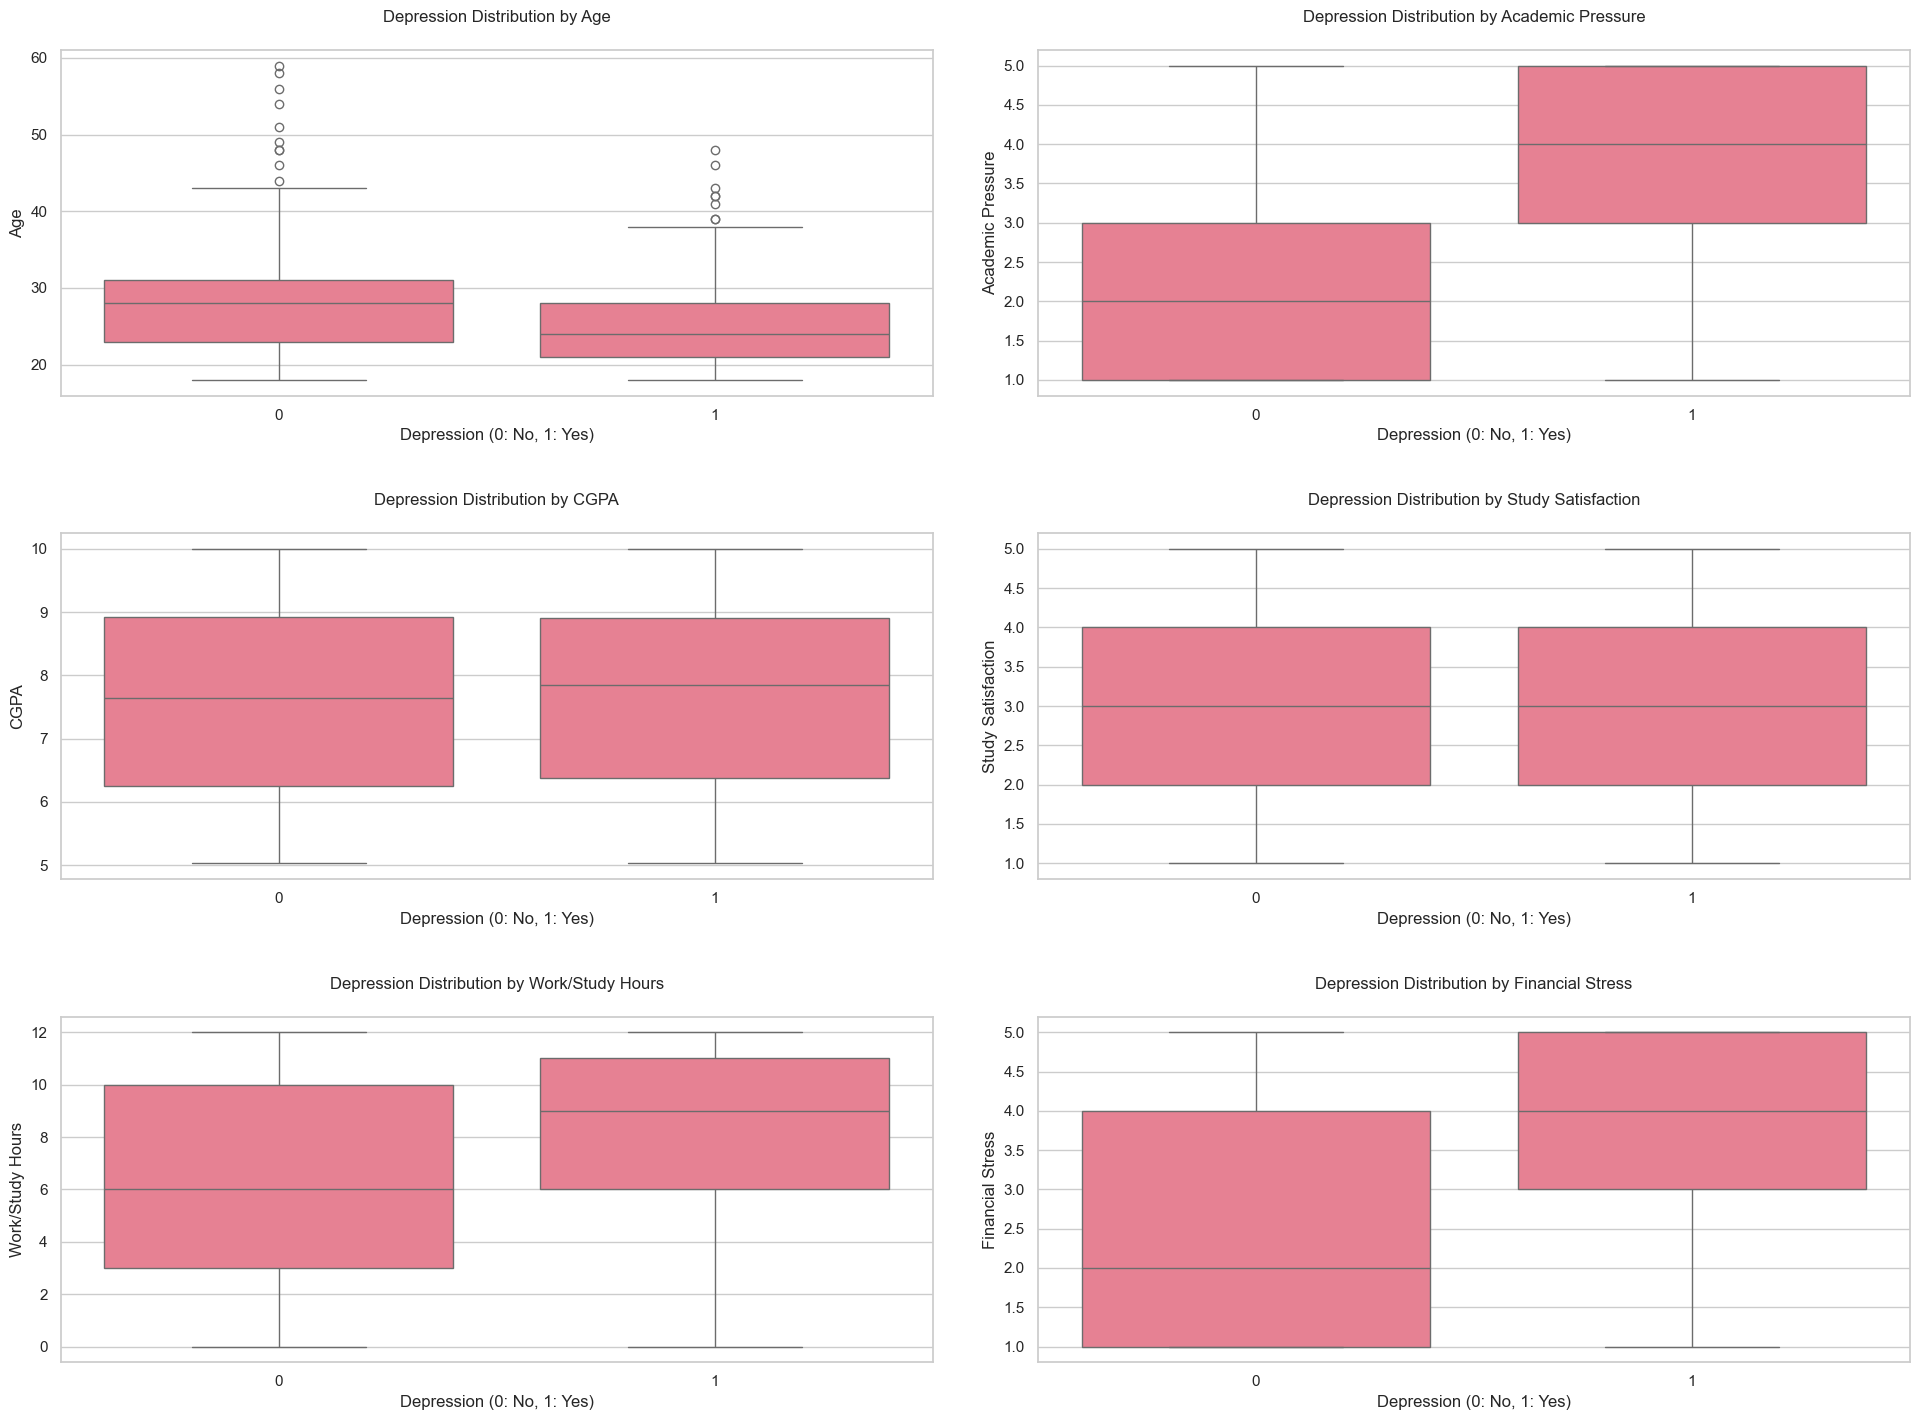


Statistical Summary of Numerical Features by Target

--------------------------------------------------
Feature: Age
              count       mean       std   min   25%   50%   75%   max
Depression                                                            
0           11815.0  27.145747  4.940333  18.0  23.0  28.0  31.0  59.0
1           16588.0  24.892332  4.659709  18.0  21.0  24.0  28.0  48.0

--------------------------------------------------
Feature: Academic Pressure
              count      mean       std  min  25%  50%  75%  max
Depression                                                      
0           11815.0  2.362421  1.251311  1.0  1.0  2.0  3.0  5.0
1           16588.0  3.693393  1.188067  1.0  3.0  4.0  5.0  5.0

--------------------------------------------------
Feature: CGPA
              count      mean       std   min   25%   50%   75%   max
Depression                                                           
0           11815.0  7.618135  1.483634  5.03  6.25  

In [81]:
sns.set_palette("husl")
def plot_numerical_distributions(df, columns_to_remove):
    numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    # Removing flads and target variable from numerical columns
    numerical_cols.remove('Work_Student_Status')
    for col in columns_to_remove:
        if col in numerical_cols:
            numerical_cols.remove(col)
    numerical_cols.remove(LABEL)  # Exclude target variable

    # 1. Target Distribution across Numerical Features
    print("Target Distribution Across Numerical Features")
    fig = plt.figure(figsize=(20, 5*((len(numerical_cols)+1)//2)))

    for idx, feature in enumerate(numerical_cols, 1):
        plt.subplot((len(numerical_cols)+1)//2, 2, idx)
        
        # Create boxplot
        sns.boxplot(x='Depression', y=feature, data=df)
        plt.title(f'Depression Distribution by {feature}', pad=20)
        plt.xlabel('Depression (0: No, 1: Yes)')
        plt.ylabel(feature)
        
    plt.tight_layout(pad=3.0)
    plt.show()

    # Additional Statistical Summary for Numerical Features
    print("\nStatistical Summary of Numerical Features by Target")
    for feature in numerical_cols:
        print(f"\n{'-'*50}")
        print(f"Feature: {feature}")
        print(df.groupby('Depression')[feature].describe())

plot_numerical_distributions(df[df['Work_Student_Status']==0], columns_to_remove = prof_cols)  # For Students

Target Distribution Across Numerical Features


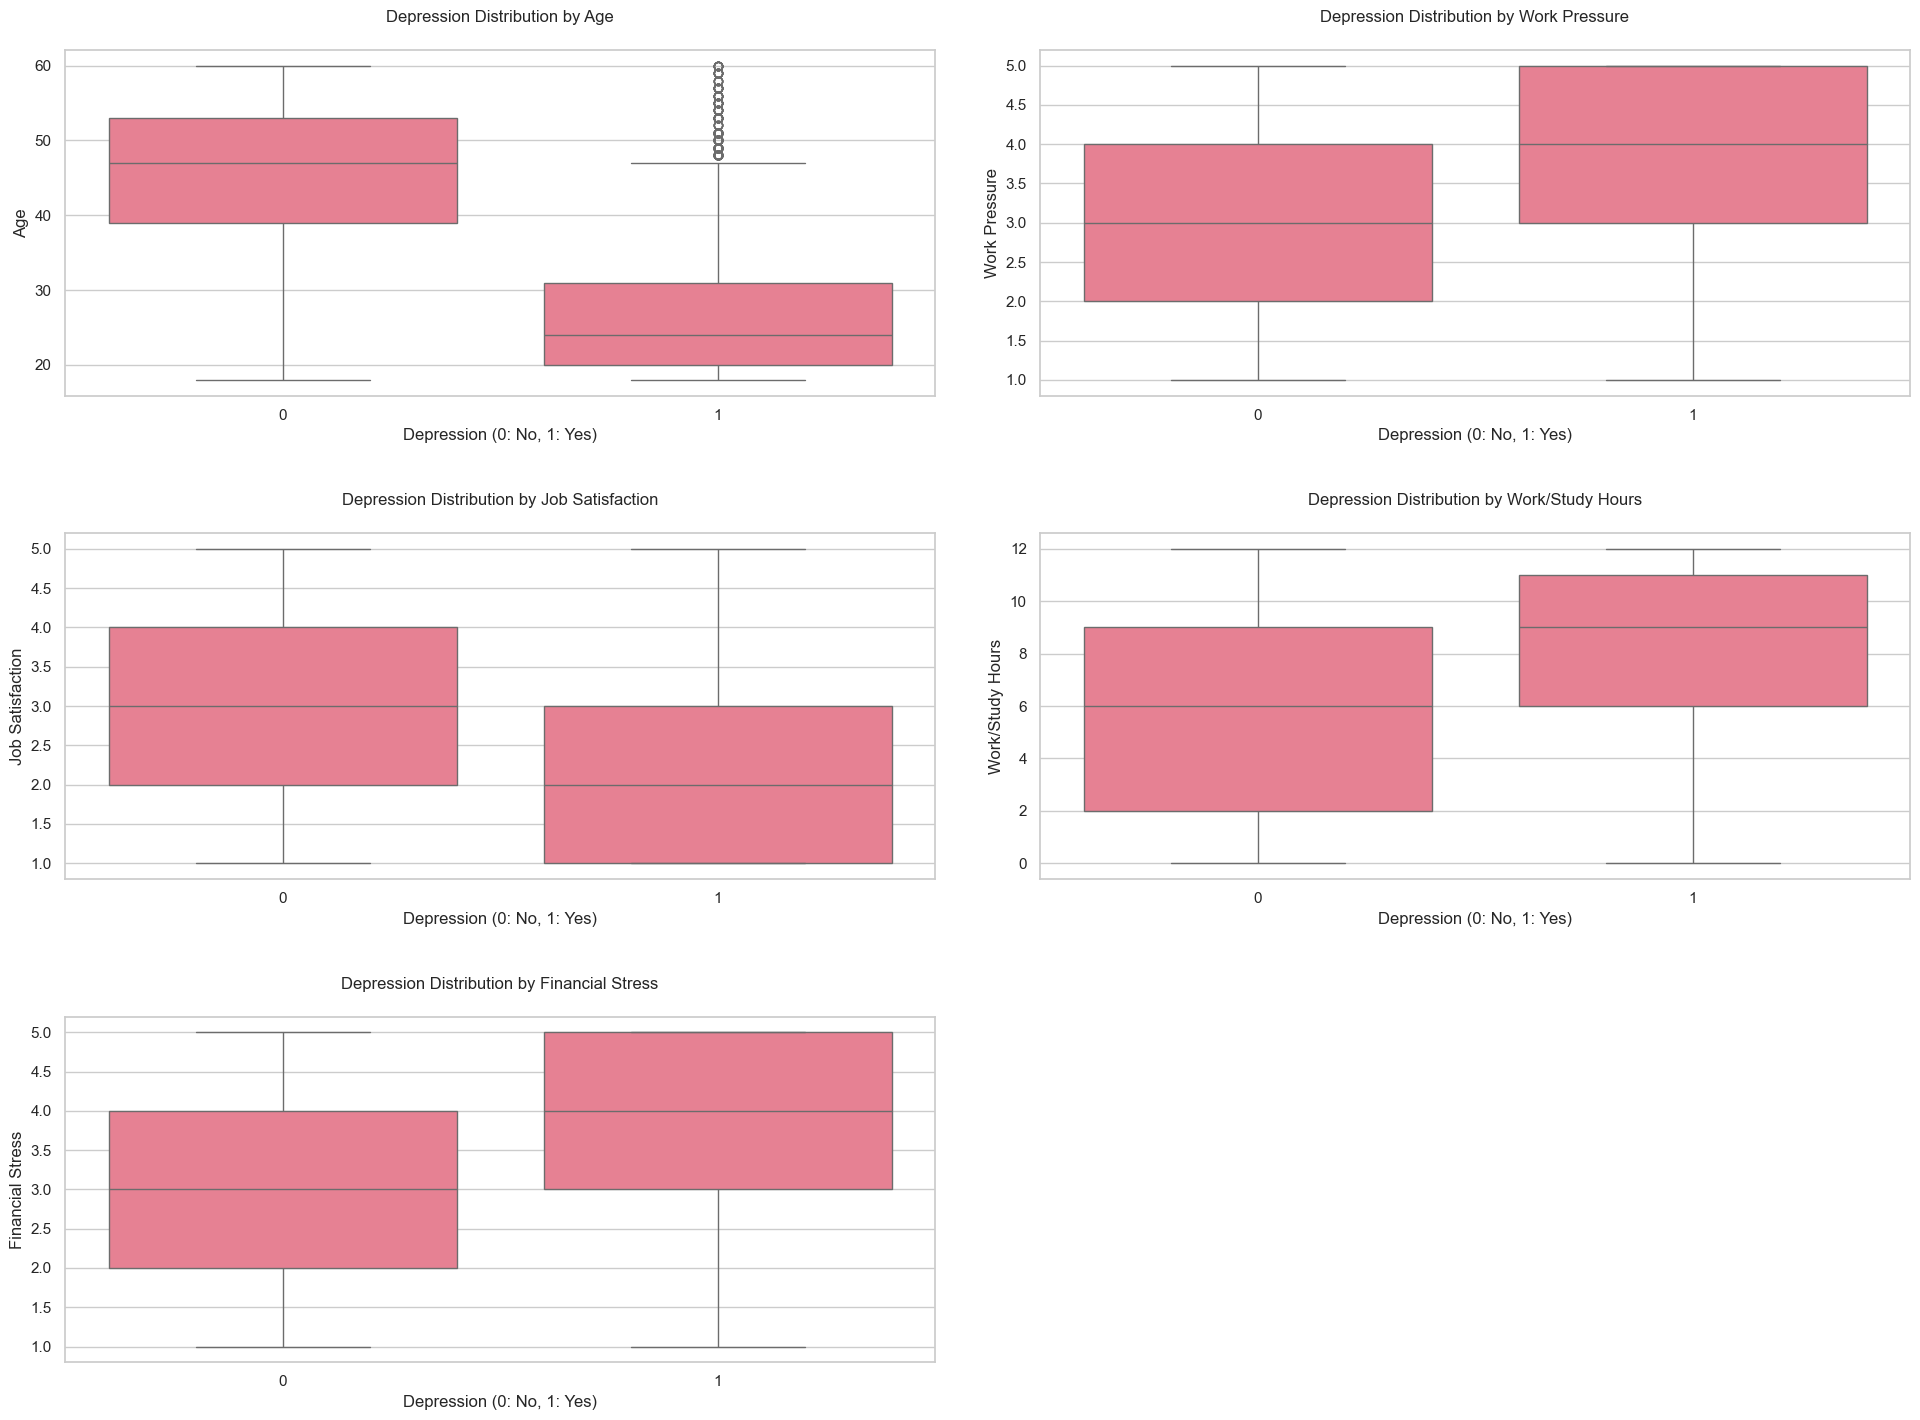


Statistical Summary of Numerical Features by Target

--------------------------------------------------
Feature: Age
               count       mean       std   min   25%   50%   75%   max
Depression                                                             
0           105385.0  45.502576  9.752436  18.0  39.0  47.0  53.0  60.0
1             9353.0  26.809580  8.724933  18.0  20.0  24.0  31.0  60.0

--------------------------------------------------
Feature: Work Pressure
               count      mean       std  min  25%  50%  75%  max
Depression                                                       
0           105385.0  2.908384  1.387588  1.0  2.0  3.0  4.0  5.0
1             9353.0  4.010050  1.194381  1.0  3.0  4.0  5.0  5.0

--------------------------------------------------
Feature: Job Satisfaction
               count      mean       std  min  25%  50%  75%  max
Depression                                                       
0           105385.0  3.046401  1.402433  1.0

In [82]:
plot_numerical_distributions(df[df['Work_Student_Status']==1], columns_to_remove = student_cols)  # For Professionals

### Feature Engineering
Transforming original columns values for proper processing

In [83]:
def process_sleep_duration(duration):
    try:
        # Handle NaN
        if pd.isna(duration):
            return np.nan, np.nan
            
        duration = str(duration).lower().replace('hours', '').strip()
        
        # Handle 'more than' or 'less than' cases
        if 'more than' in duration:
            return float(duration.replace('more than', '').strip()), 12  # assuming 12 as max
        if 'less than' in duration or 'than' in duration:
            return 0, float(duration.replace('less than', '').replace('than', '').strip())
        
        # Handle weekly hours - if number is too large, divide by 7
        if '-' not in duration:
            try:
                hours = float(duration)
                if hours > 24:  # if more than 24, assume it's weekly
                    daily = hours/7
                    return daily, daily
                return hours, hours
            except:
                return np.nan, np.nan
                
        # Handle ranges
        start, end = duration.split('-')
        start = float(start)
        end = float(end)
        
        # Fix reversed ranges (like 9-6 to 6-9)
        if start > end:
            start, end = end, start
            
        # If range is too large, divide by 7 (weekly to daily)
        if end > 24:
            start = start/7
            end = end/7
            
        return start, end
    except:
        return np.nan, np.nan
    
# Function to transform categorical columns
def transform_categorical_columns(df):
   """ 
   Here, the previous method is applied as an extra step to the data processing
   """
   # Convert 'Yes'/'No' to 1/0 and rename columns
   df['family_history'] = (df['Family History of Mental Illness'].str.lower() == 'yes').astype(int)
   df['suicidal'] = (df['Suicidal_Thoughts'].str.lower() == 'yes').astype(int) 
   # Convert Gender to binary (Female = 0, Male = 1)
   df['Gender'] = (df['Gender'] == 'Male').astype(int)
   
   # Clean Dietary Habits - convert invalid categories to NaN
   valid_dietary = ['Healthy', 'Unhealthy', 'Less Healthy', 'More Healthy', 
                   '5 Healthy', '5 Unhealthy', 'Moderate', 'No Healthy',
                   'Less than Healthy']
   df.loc[~df['Dietary Habits'].isin(valid_dietary), 'Dietary Habits'] = np.nan
    
   df[['Min_sleep', 'Max_sleep']] = df['Sleep Duration'].apply(process_sleep_duration).apply(pd.Series)
    
   # Drop the original columns
   df = df.drop(['Family History of Mental Illness', 'Suicidal_Thoughts', 'Sleep Duration'], axis=1)
   return df

In [84]:
df = transform_categorical_columns(df)
df['Dietary Habits'].value_counts()

Dietary Habits
Moderate             50506
Unhealthy            47044
Healthy              45564
More Healthy             2
Less than Healthy        1
No Healthy               1
Less Healthy             1
Name: count, dtype: int64

Degrees show a lot of inconsistency due to wrong and unclean entries, This is fixed using the method below:

In [85]:
import string
def clean_degree_and_related_columns(df):
    """
    Clean and standardize degree-related columns in a DataFrame based on the exact set of degrees present.
    
    Parameters:
        df (pandas.DataFrame): Input DataFrame containing 'Degree' column
        
    Returns:
        pandas.DataFrame: Cleaned DataFrame with standardized degrees
    """
    df = df.copy()
    
    # Exact degree standardization mapping based on the data
    degree_standardization = {
        # Bachelor's Degrees
        "btech": "B.Tech",
        "b.tech": "B.Tech",
        "b tech": "B.Tech",
        "btech": "B.Tech",
        "b b.tech": "B.Tech",
        "mechanical engineer": "B.Tech",
        
        "bcom": "B.Com",
        "b.com": "B.Com",
        "b_com": "B.Com",
        "b.m.com": "B.Com",
        "degree": "B.Com",  # Based on previous mapping
        
        "bsc": "B.Sc",
        "b.sc": "B.Sc",
        
        "barch": "B.Arch",
        "b.arch": "B.Arch",
        
        "bca": "BCA",
        "b.ca": "BCA",
        "b bca": "BCA",
        "bhca": "BCA",
        
        "ba": "BA",
        
        "bba": "BBA",
        "b.ba": "BBA",
        
        "be": "BE",
        
        "bed": "B.Ed",
        "b.ed": "B.Ed",
        "a.ed": "B.Ed",
        "e.ed": "B.Ed",
        "i.ed": "B.Ed",
        "g.ed": "B.Ed",
        "j.ed": "B.Ed",
        "k.ed": "B.Ed",
        
        "bpharm": "B.Pharm",
        "b.pharm": "B.Pharm",
        "b_pharm": "B.Pharm",
        "b._pharm": "B.Pharm",
        "s.pharm": "B.Pharm",
        
        "bhm": "BHM",
        "b.h": "BHM",
        "bh": "BHM",
        
        # Master's Degrees
        "mtech": "M.Tech",
        "m.tech": "M.Tech",
        
        "mcom": "M.Com",
        "m.com": "M.Com",
        
        "msc": "MSc",
        
        "mca": "MCA",
        "gca": "MCA",
        "rca": "MCA",
        "pca": "MCA",
        
        "ma": "MA",
        "m.": "MA",
        "m": "MA",
        
        "mba": "MBA",
        
        "me": "ME",
        
        "med": "M.Ed",
        "m.ed": "M.Ed",
        "m.m.ed": "M.Ed",
        "m.b.ed": "M.Ed",
        
        "march": "M.Arch",
        "m.arch": "M.Arch",
        
        "mpharm": "M.Pharm",
        "m.pharm": "M.Pharm",
        
        "mhm": "MHM",
        
        # Other Professional Degrees
        "llb": "LLB",
        "llm": "LLM",
        "phd": "PhD",
        "mbbs": "MBBS",
        "md": "MD",
        
        # School Education
        "class12": "Class 12",
        "class 12": "Class 12",
        "12th": "Class 12"
    }
    
    # Names found in the degree column
    names = {
        'advait', 'vibha', 'gagan', 'eshita', 'navya', 'bian', 'kavya', 
        'vrinda', 'moham', 'magan', 'rupak', 'aadhya', 'banchal'
    }
    
    # Cities found in the degree column
    cities = {'pune', 'bhopal'}
    
    # Job titles found in the degree column
    job_titles = {
        'business analyst', 'travel consultant', 'financial analyst'
    }
    
    def standardize_text(text):
        """Standardize text by converting to lowercase and removing punctuation/spaces"""
        if pd.isna(text):
            return ''
        text = str(text).lower()
        text = ''.join(c for c in text if c not in string.punctuation)
        return text.replace(' ', '')
    
    def is_numeric(x):
        """Check if a value can be converted to float"""
        try:
            float(x)
            return True
        except (ValueError, TypeError):
            return False
    
    def standardize_degree(degree, degree_std):
        """Standardize degree values based on mapping and patterns"""
        if pd.isna(degree):
            return degree
            
        # Return NaN for non-degree values
        if (degree_std in job_titles or 
            degree_std in names or 
            degree_std in cities or 
            is_numeric(degree)):
            return np.nan
            
        # Check standardization mapping
        if degree_std in degree_standardization:
            return degree_standardization[degree_std]
        
        # Handle special cases
        if 'b.gender' in degree_std:
            return np.nan
        if 'b.study_hours' in degree_std:
            return np.nan
        if 'b.press' in degree_std:
            return np.nan
        if 'm.ui' in degree_std:
            return np.nan
            
        return np.nan
    
    # Standardize degree text for comparison
    df['Degree_std'] = df['Degree'].apply(standardize_text)
    
    # Handle job titles
    job_mask = df['Degree_std'].apply(lambda x: any(job in x for job in job_titles))
    df.loc[job_mask & df['Profession'].isna(), 'Profession'] = df.loc[job_mask, 'Degree']
    
    # Handle CGPA values - specific values seen in data: '5.65', '3.0', '8.95', '20'
    cgpa_mask = df['Degree'].apply(lambda x: isinstance(x, (int, float)) or 
                                 (isinstance(x, str) and is_numeric(x)))
    df.loc[cgpa_mask, 'CGPA'] = df.loc[cgpa_mask, 'Degree'].apply(
        lambda x: float(x) if is_numeric(x) and float(x) <= 10 else np.nan)
    
    # Standardize degrees
    df['Degree'] = df.apply(lambda x: standardize_degree(x['Degree'], x['Degree_std']), axis=1)
    
    # Drop temporary standardization column
    df = df.drop('Degree_std', axis=1)
    
    return df
print("Before cleaning: ", len(df['Degree'].value_counts()))
df = clean_degree_and_related_columns(df)
print("After cleaning: ", len(df['Degree'].value_counts()))

Before cleaning:  115
After cleaning:  28


Same process as before, but for the profession column. We are trying to normalize the profession column to make it easier for the model to learn from it and reduce the amount of overlapping profession names.

In [86]:
def clean_profession_column(df):
    df = df.copy()
    
    # Standardize format: lowercase, remove punctuation and extra spaces
    df['Profession_std'] = df['Profession'].fillna('').astype(str).str.lower()
    df['Profession_std'] = df['Profession_std'].apply(lambda x: ''.join(c for c in x if c not in string.punctuation))
    df['Profession_std'] = df['Profession_std'].str.replace(' ', '')
    
    # 1. Names to convert to NaN
    names = {
        'manvi', 'pranav', 'samar', 'simran', 'yogesh', 'yuvraj'
    }
    
    
    # 3. Degrees to be moved to Degree column if Degree is NaN
    degrees = {
        'bcom': 'B.Com',
        'bed': 'B.Ed',
        'bpharm': 'B.Pharm',
        'bba': 'BBA',
        'bca': 'BCA',
        'be': 'BE',
        'llm': 'LLM',
        'med': 'M.Ed',
        'mpharm': 'M.Pharm',
        'mtech': 'M.Tech',
        'mba': 'MBA',
        'mbbs': 'MBBS',
        'mca': 'MCA',
        'md': 'MD',
        'me': 'ME',
        'phd': 'PhD'
    }
    
    for prof_std, degree in degrees.items():
        mask = (df['Profession_std'] == prof_std) & df['Degree'].isna()
        df.loc[mask, 'Degree'] = degree
    
    # 4. Invalid/nonsensical entries to convert to NaN
    invalid_entries = {
        '24th', '3m', 'moderate', 'no', 'name', 'profession', 'unhealthy', 
        'unveil', 'familyvirar', 'dev'
    }
    
    # 5. Standardize similar professions
    profession_standardization = {
        'academic': 'Teacher',
        'medicaldoctor': 'Doctor',
        'financialanalyst': 'Financial Analyst',
        'finanancialanalyst': 'Financial Analyst',
        'businessanalyst': 'Business Analyst',
        'softwareengineer': 'Software Engineer',
        'civilengineer': 'Civil Engineer',
        'mechanicalengineer': 'Mechanical Engineer',
        'cityconsultant': 'City Consultant',
        'educationalconsultant': 'Educational Consultant',
        'familyconsultant': 'Family Consultant',
        'travelconsultant': 'Travel Consultant',
        'digitalmarketer': 'Digital Marketer',
        'marketingmanager': 'Marketing Manager',
        'hrmanager': 'HR Manager',
        'citymanager': 'City Manager',
        'graphicdesigner': 'Graphic Designer',
        'uxuidesigner': 'UX/UI Designer',
        'contentwriter': 'Content Writer',
        'investmentbanker': 'Investment Banker',
        'salesexecutive': 'Sales Executive',
        'customersupport': 'Customer Support',
        'researchanalyst': 'Research Analyst',
        'workingprofessional': 'Working Professional'
    }
    
    def standardize_profession(prof, prof_std):
        if pd.isna(prof) or prof_std == '':
            return np.nan
            
        # Return NaN for names, cities, and invalid entries
        if (prof_std in names or 
            prof_std in invalid_entries or prof_std in degrees.keys()):
            return np.nan
            
        # Return standardized profession if it exists
        if prof_std in profession_standardization:
            return profession_standardization[prof_std]
            
        # Return original profession if it's already standard
        if prof in ['Accountant', 'Analyst', 'Architect', 'Chef', 'Chemist',
                   'Consultant', 'Data Scientist', 'Doctor', 'Electrician',
                   'Entrepreneur', 'Judge', 'Lawyer', 'Manager', 'Pharmacist',
                   'Pilot', 'Plumber', 'Researcher', 'Student', 'Surgeon',
                   'Teacher', 'Unemployed']:
            return prof
            
        return np.nan
    
    # Apply standardization
    df['Profession'] = df.apply(lambda x: standardize_profession(x['Profession'], x['Profession_std']), axis=1)
    
    # Drop temporary column
    df = df.drop('Profession_std', axis=1)
    
    return df
print("Before Cleaning:", len(df['Profession'].unique()))
df = clean_profession_column(df)
print("After Cleaning:", len(df['Profession'].unique()))

Before Cleaning: 65
After Cleaning: 41


In [87]:
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
categorical_features

['Profession', 'Dietary Habits', 'Degree']

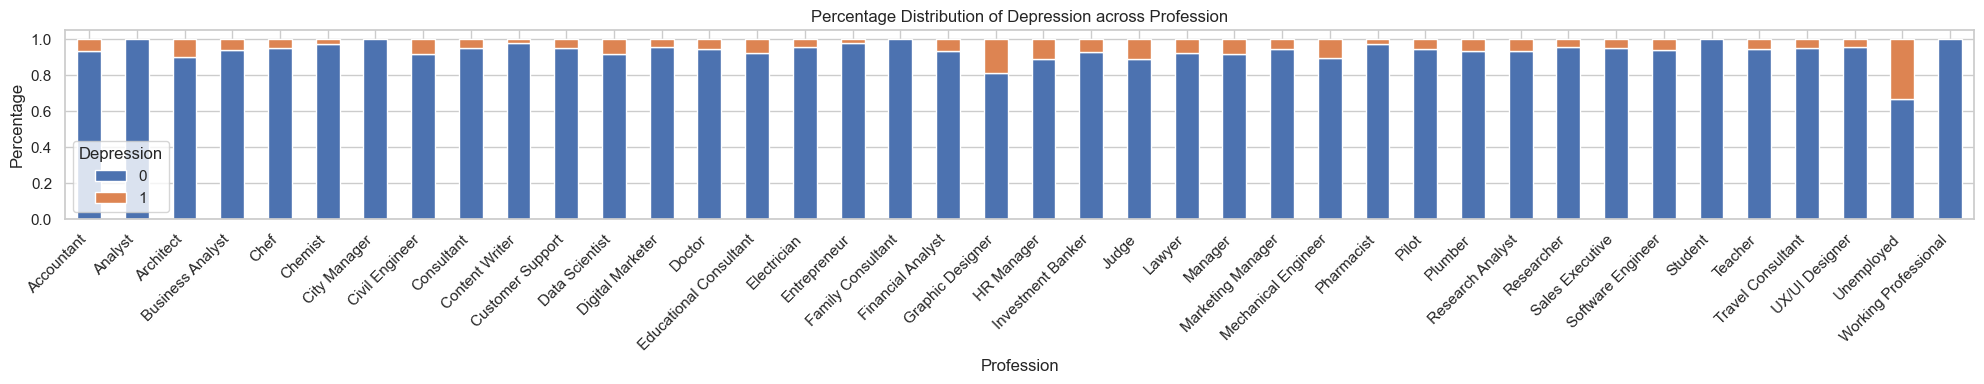

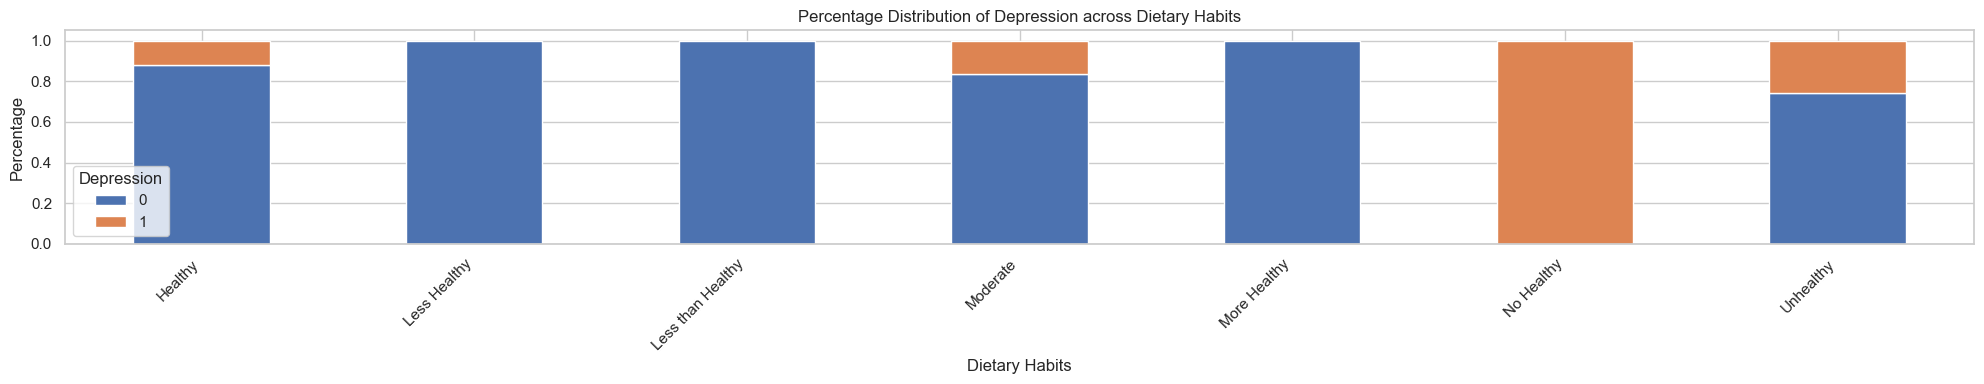

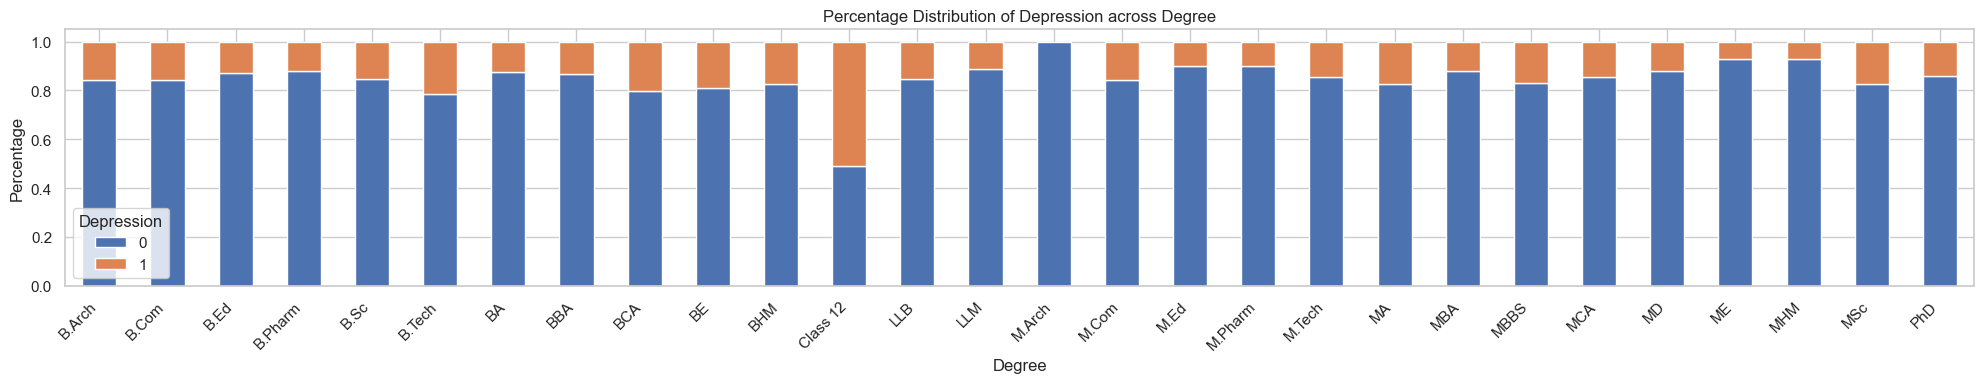

In [ ]:
import seaborn as sns
sns.set_palette("husl")

# Plot for each categorical feature
for col in categorical_features:
  
    # Create contingency table with normalized values (percentages)
    contingency_table = pd.crosstab(df[col], df['Depression'], normalize='index')
    
    # Set style
    sns.set_theme(style="whitegrid")
    
    # Create stacked bar plot
    contingency_table.plot(kind="bar", 
                    stacked=True, 
                    figsize=(20, 4))
    
    # Customize plot
    plt.title(f"Percentage Distribution of Depression across {col}")
    plt.xlabel(col)
    plt.ylabel("Percentage")
    plt.legend(title="Depression")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [89]:
missing_report(df)

,Columns,Missing Values Percentage
0,Gender,0.000000
1,Age,0.000000
2,Work_Student_Status,0.000000
3,Profession,26.018401
4,Academic Pressure,0.000000
5,Work Pressure,0.000000
6,CGPA,0.003493
7,Study Satisfaction,0.000000
8,Job Satisfaction,0.000000
9,Dietary Habits,0.015369


### Handling Missing Data After Processing
Althought I have handled inconsistent data in the previous step, I need to handle missing data in the dataset that comes as a result of the previous step.

In [90]:
# Handling other null values by replacing them with the median or mode of their respective columns
df['Profession'] = df['Profession'].fillna('Unknown')

# Replacing missing values 
for small_cat in ['Dietary Habits', 'Degree']:
    if small_cat in df.columns:
        df[small_cat] = df[small_cat].fillna('Unknown')

# Replacing missing values in Min and Max sleep hours
for sleep_col in ['Min_sleep', 'Max_sleep','CGPA']:
    if sleep_col in df.columns:
        df[sleep_col] = df[sleep_col].fillna(df[sleep_col].median())


In [91]:
missing_report(df)

,Columns,Missing Values Percentage
0,Gender,0.000000
1,Age,0.000000
2,Work_Student_Status,0.000000
3,Profession,0.000000
4,Academic Pressure,0.000000
5,Work Pressure,0.000000
6,CGPA,0.000000
7,Study Satisfaction,0.000000
8,Job Satisfaction,0.000000
9,Dietary Habits,0.000000


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 143141 entries, 0 to 143255
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Gender               143141 non-null  int64  
 1   Age                  143141 non-null  float64
 2   Work_Student_Status  143141 non-null  int64  
 3   Profession           143141 non-null  object 
 4   Academic Pressure    143141 non-null  float64
 5   Work Pressure        143141 non-null  float64
 6   CGPA                 143141 non-null  float64
 7   Study Satisfaction   143141 non-null  float64
 8   Job Satisfaction     143141 non-null  float64
 9   Dietary Habits       143141 non-null  object 
 10  Degree               143141 non-null  object 
 11  Work/Study Hours     143141 non-null  float64
 12  Financial Stress     143137 non-null  float64
 13  Depression           143141 non-null  int64  
 14  family_history       143141 non-null  int64  
 15  suicidal             1

In [93]:
# Impute 'Financial Stress' with median
if 'Financial Stress' in df.columns:
    df['Financial Stress'] = df['Financial Stress'].fillna(df['Financial Stress'].median())
missing_report(df)

,Columns,Missing Values Percentage
0,Gender,0.0
1,Age,0.0
2,Work_Student_Status,0.0
3,Profession,0.0
4,Academic Pressure,0.0
5,Work Pressure,0.0
6,CGPA,0.0
7,Study Satisfaction,0.0
8,Job Satisfaction,0.0
9,Dietary Habits,0.0


### Preparing Data for Output

In this section, we will prepare the data for output by creating a pipeline that will transform the data and then output the data to a csv file.

In [94]:
# Data Preprocessing Pipeline & Splitting
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer


#Define Feature Groups
numeric_features = ['Age', 'Work/Study Hours', 'Financial Stress', 'Min_sleep', 'Max_sleep']
categorical_features = ['Profession', 'Dietary Habits', 'Degree']
# Columns to pass through (Binary + Sentinel-based Ordinal/Continuous)
passthrough_features = ['Gender', 'Work_Student_Status', 'family_history', 'suicidal', 
                        'Academic Pressure', 'Work Pressure', 'CGPA', 
                        'Study Satisfaction', 'Job Satisfaction']


Let's define our pipeline and preprocessor.

In [95]:

# 3. Define Transformers
# Numerical: Impute missing (for Financial Stress) -> Scale
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical: One-Hot Encode
cat_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Combine into Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numeric_features),
        ('cat', cat_transformer, categorical_features),
        ('pass', 'passthrough', passthrough_features)
    ],
    verbose_feature_names_out=False # Keep column names clean
)


In [96]:
df[LABEL].value_counts(normalize=True)

Depression
0    0.818773
1    0.181227
Name: proportion, dtype: float64

In [62]:

# 4. Split Data (Train/Val/Test)
X = df.drop('Depression', axis=1)
y = df['Depression']

# First split: 80% Train, 20% Temp (Val + Test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Second split: Split Temp into 50% Val, 50% Test (resulting in 10% each of total)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)


In [65]:

# 5. Fit and Transform
# Fit ONLY on Training data to prevent leakage
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

In [66]:

# Get feature names for reconstruction (optional, helpful for debugging)
try:
    feature_names = preprocessor.get_feature_names_out()
    # Reconstruct DataFrames
    X_train_df = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
    X_val_df = pd.DataFrame(X_val_processed, columns=feature_names, index=X_val.index)
    X_test_df = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)
except AttributeError:
    # Fallback if get_feature_names_out fails (older sklearn versions)
    print("Warning: Could not retrieve feature names automatically.")
    X_train_df = pd.DataFrame(X_train_processed, index=X_train.index)
    X_val_df = pd.DataFrame(X_val_processed, index=X_val.index)
    X_test_df = pd.DataFrame(X_test_processed, index=X_test.index)

print("Data Processing Complete.")
print(f"Training Set Shape: {X_train_df.shape}")
print(f"Validation Set Shape: {X_val_df.shape}")
print(f"Test Set Shape: {X_test_df.shape}")
print("\nFirst 5 rows of processed training data:")
display(X_train_df.head())

Data Processing Complete.
Training Set Shape: (114512, 91)
Validation Set Shape: (14314, 91)
Test Set Shape: (14315, 91)

First 5 rows of processed training data:


,Age,Work/Study Hours,Financial Stress,Min_sleep,Max_sleep,Profession_Accountant,Profession_Analyst,Profession_Architect,Profession_Business Analyst,Profession_Chef,...,Degree_Unknown,Gender,Work_Student_Status,family_history,suicidal,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction
33405,1.020610,1.493394,1.424242,0.680963,0.133947,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,0.0,-1.0,1.0,-1.00,-1.0,5.0
63198,-0.594903,0.974397,1.424242,0.997055,1.646268,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,4.0,-1.0,8.55,5.0,-1.0
103749,-1.321884,0.714899,0.011180,0.680963,0.133947,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,4.0,-1.0,6.00,3.0,-1.0
6468,-1.564211,1.493394,-0.695351,0.997055,1.646268,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,3.0,-1.0,6.74,1.0,-1.0
133299,-1.402660,-1.620587,-0.695351,0.997055,1.646268,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,1.0,-1.0,3.0,-1.00,-1.0,2.0


### Export the data as CSV

In [67]:
X_train_df.to_csv('data/dataset2/X_train_processed.csv', index=False)
X_val_df.to_csv('data/dataset2/X_val_processed.csv', index=False)
X_test_df.to_csv('data/dataset2/X_test_processed.csv', index=False)

y_train.to_csv('data/dataset2/y_train.csv', index=False)
y_val.to_csv('data/dataset2/y_val.csv', index=False)
y_test.to_csv('data/dataset2/y_test.csv', index=False)
